# Credit Risk Analysis — Loan Default Prediction
### 32,581 borrowers | 12 features | Binary classification (Default vs No Default)

---

## Project Question
**Which borrowers are most likely to default on a loan?**

Credit risk is the core function of any bank or lending institution.
This project analyzes borrower data, identifies the key factors that
drive loan defaults, and builds a classification model to predict
whether a new borrower will default.

**Target variable:** `loan_status` — 0 = No Default, 1 = Default

---

## Steps
1. Load and explore the data
2. Clean missing values
3. EDA — understand what drives defaults
4. Feature engineering
5. Build and evaluate a prediction model
6. Identify most important risk factors
7. Conclusions

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('All libraries imported.')

All libraries imported.


In [2]:

df = pd.read_csv('credit_risk_dataset.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nDefault rate:', df['loan_status'].mean().round(3),
      '(', round(df['loan_status'].mean()*100, 1), '% of borrowers defaulted )')

Shape: (32581, 12)

Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Default rate: 0.218 ( 21.8 % of borrowers defaulted )


In [3]:

df.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [4]:

print(df.dtypes)
print('\n')
df.describe().round(2)

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object




,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


In [5]:

nulls = df.isnull().sum()
pct   = (nulls / len(df) * 100).round(2)

missing = pd.DataFrame({'Missing Count': nulls, 'Missing %': pct})
print(missing[missing['Missing Count'] > 0])

                   Missing Count  Missing %
person_emp_length            895       2.75
loan_int_rate               3116       9.56


In [7]:

df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
)


df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())


df = df[df['person_age'] <= 100].copy()

print('Missing values after cleaning:')
print(df.isnull().sum())
print('\nRows after cleaning:', len(df))

Missing values after cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Rows after cleaning: 32576


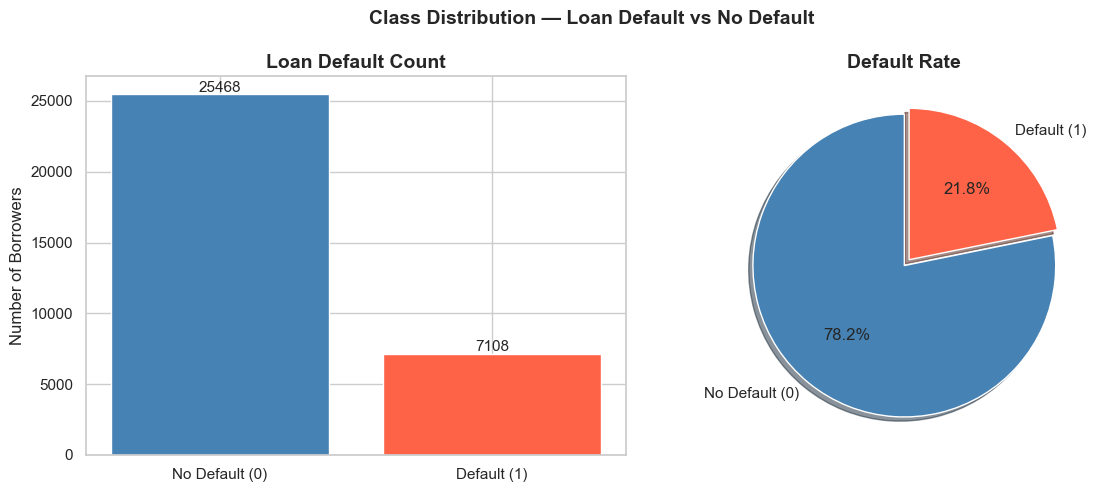

In [8]:


counts = df['loan_status'].value_counts()
labels = ['No Default (0)', 'Default (1)']
colors = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


axes[0].bar(labels, counts.values, color=colors, edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontsize=11)
axes[0].set_title('Loan Default Count')
axes[0].set_ylabel('Number of Borrowers')


axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            explode=(0, 0.05), shadow=True)
axes[1].set_title('Default Rate')

plt.suptitle('Class Distribution — Loan Default vs No Default', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

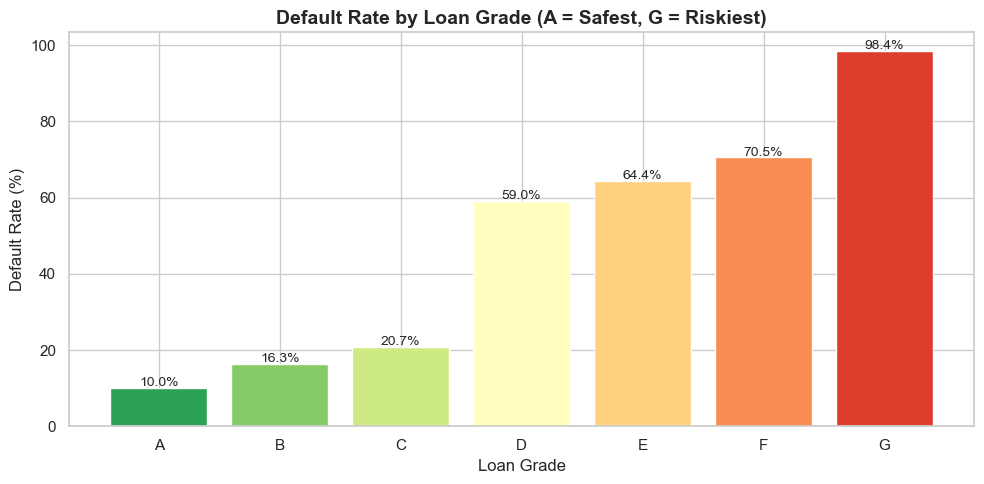

In [9]:


grade_default = df.groupby('loan_grade')['loan_status'].mean().sort_index() * 100

plt.figure(figsize=(10, 5))

# Color bars from green (low risk) to red (high risk)
colors = sns.color_palette('RdYlGn_r', len(grade_default))
bars = plt.bar(grade_default.index, grade_default.values,
               color=colors, edgecolor='white')

for bar, val in zip(bars, grade_default.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10)

plt.title('Default Rate by Loan Grade (A = Safest, G = Riskiest)')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

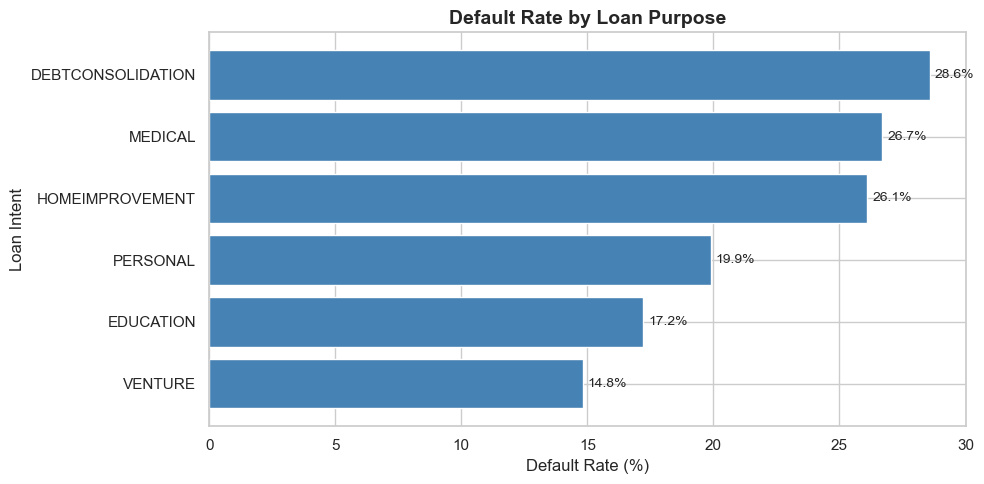

In [10]:

intent_default = (df.groupby('loan_intent')['loan_status']
                  .mean()
                  .sort_values(ascending=True) * 100)

plt.figure(figsize=(10, 5))

plt.barh(intent_default.index, intent_default.values,
         color='steelblue', edgecolor='white')

for i, v in enumerate(intent_default.values):
    plt.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)

plt.title('Default Rate by Loan Purpose')
plt.xlabel('Default Rate (%)')
plt.ylabel('Loan Intent')
plt.tight_layout()
plt.show()

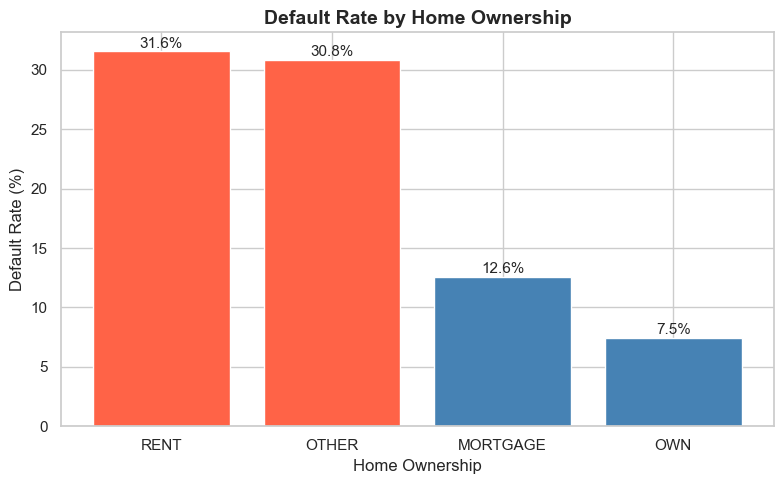

In [11]:


home_default = (df.groupby('person_home_ownership')['loan_status']
                .mean()
                .sort_values(ascending=False) * 100)

plt.figure(figsize=(8, 5))

colors = ['tomato' if v > 20 else 'steelblue' for v in home_default.values]
bars = plt.bar(home_default.index, home_default.values,
               color=colors, edgecolor='white')

for bar, val in zip(bars, home_default.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11)

plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

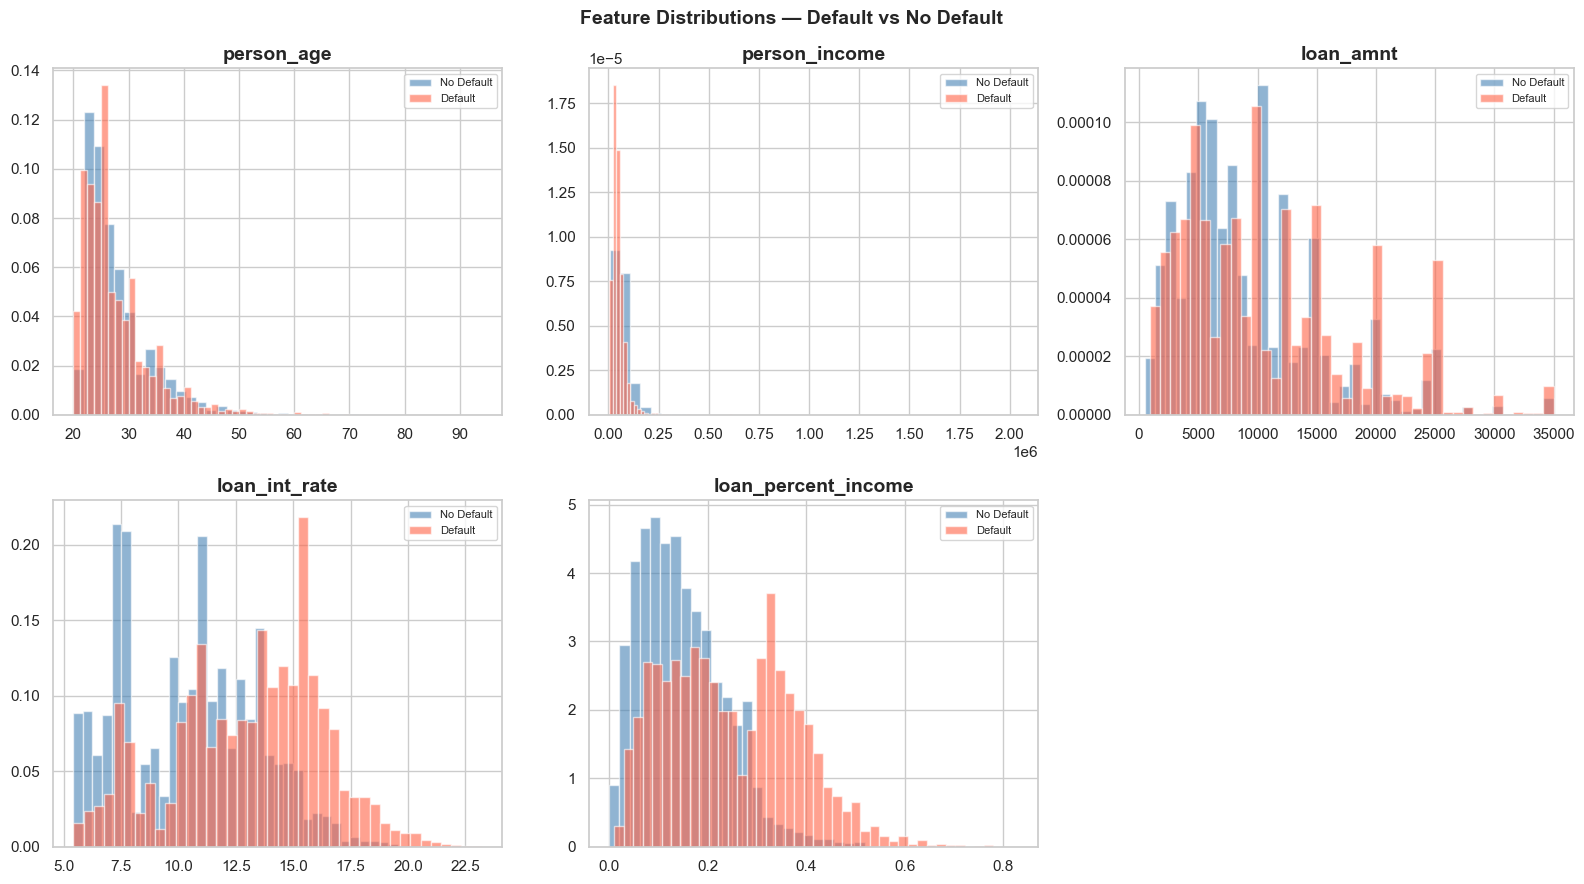

In [12]:


numeric_features = ['person_age', 'person_income', 'loan_amnt',
                    'loan_int_rate', 'loan_percent_income']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()  # flatten 2D array to 1D so we can loop easily

for i, col in enumerate(numeric_features):
    # Plot defaulted borrowers
    axes[i].hist(df[df['loan_status'] == 0][col].dropna(),
                 bins=40, alpha=0.6, color='steelblue',
                 label='No Default', density=True)
    # Plot non-defaulted borrowers on the same axis
    axes[i].hist(df[df['loan_status'] == 1][col].dropna(),
                 bins=40, alpha=0.6, color='tomato',
                 label='Default', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# Hide the 6th subplot (we only have 5 features)
axes[5].set_visible(False)

plt.suptitle('Feature Distributions — Default vs No Default', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

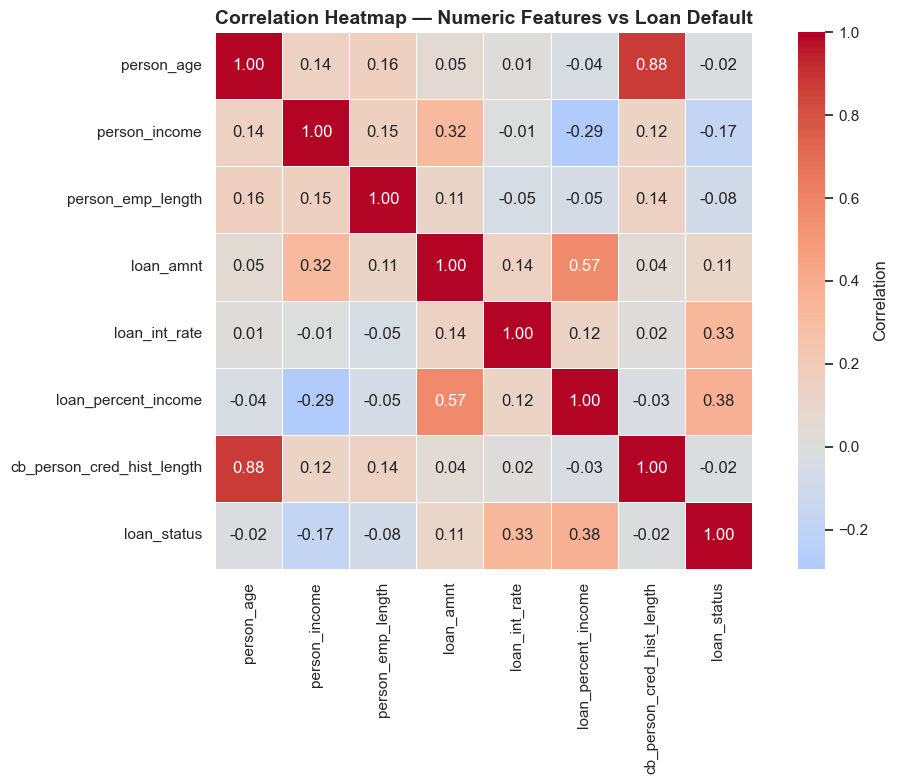

In [17]:


numeric_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length', 'loan_status']

corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            cbar_kws={'label': 'Correlation'})

plt.title('Correlation Heatmap — Numeric Features vs Loan Default')
plt.tight_layout()
plt.show()

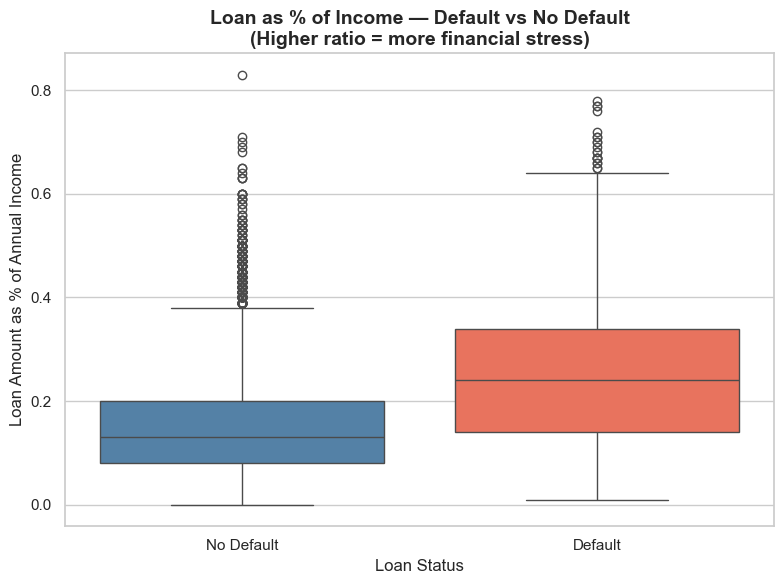

In [18]:


plt.figure(figsize=(8, 6))

# Convert loan_status to string so palette keys match
df['loan_status_label'] = df['loan_status'].map({0: 'No Default', 1: 'Default'})

sns.boxplot(data=df, x='loan_status_label', y='loan_percent_income',
            hue='loan_status_label',
            palette={'No Default': 'steelblue', 'Default': 'tomato'},
            order=['No Default', 'Default'],
            legend=False)

plt.title('Loan as % of Income — Default vs No Default\n(Higher ratio = more financial stress)')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount as % of Annual Income')
plt.tight_layout()
plt.show()

C:\Users\abhim\AppData\Local\Temp\ipykernel_21944\3633444268.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='loan_grade', y='loan_int_rate',


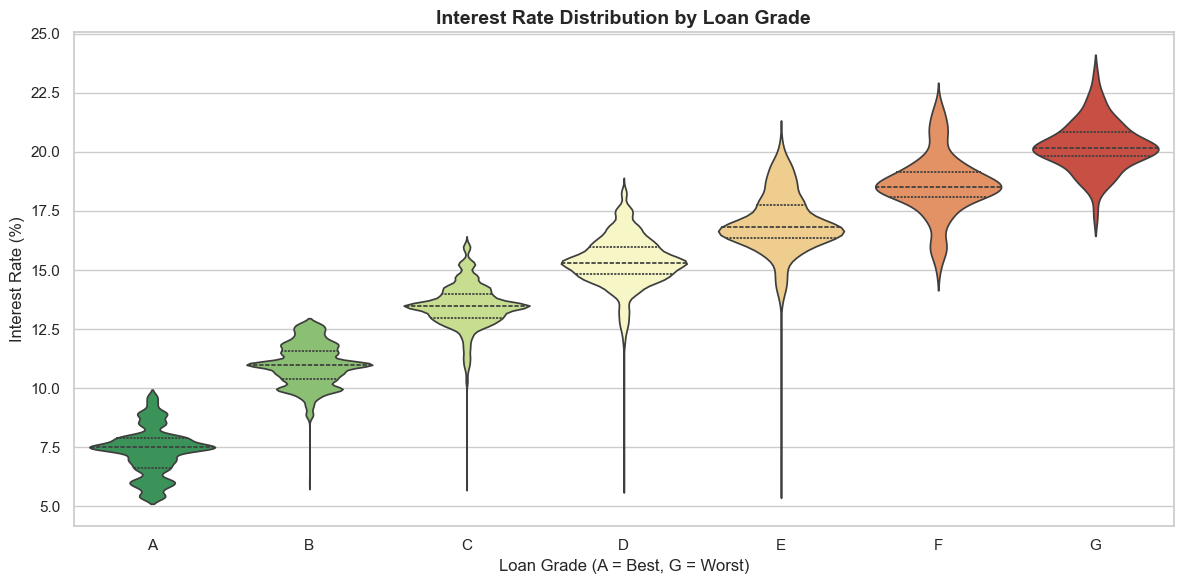

In [19]:

plt.figure(figsize=(12, 6))

sns.violinplot(data=df, x='loan_grade', y='loan_int_rate',
               palette='RdYlGn_r',
               order=['A','B','C','D','E','F','G'],
               inner='quartile')

plt.title('Interest Rate Distribution by Loan Grade')
plt.xlabel('Loan Grade (A = Best, G = Worst)')
plt.ylabel('Interest Rate (%)')
plt.tight_layout()
plt.show()

In [24]:

df_model = df.copy()


if 'loan_status_label' in df_model.columns:
    df_model = df_model.drop('loan_status_label', axis=1)

categorical_cols = ['person_home_ownership', 'loan_intent',
                    'loan_grade', 'cb_person_default_on_file']

le = LabelEncoder()

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('Encoding done.')
df_model.head()

Encoding done.


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,3,123.0,4,3,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4


In [25]:

X = df_model.drop('loan_status', axis=1)
y = df_model['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    # stratify=y ensures same default ratio in both train and test sets
)

print('Training set size:', X_train.shape)
print('Test set size:    ', X_test.shape)
print('Default rate in train:', y_train.mean().round(3))
print('Default rate in test: ', y_test.mean().round(3))

Training set size: (26060, 11)
Test set size:     (6516, 11)
Default rate in train: 0.218
Default rate in test:  0.218


In [27]:

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1       # use all CPU cores to speed up training
)

model.fit(X_train, y_train)

print('Model trained.')

Model trained.


In [28]:

# classification_report shows precision, recall, f1-score per class
# Precision = of all predicted defaults, how many were actual defaults
# Recall    = of all actual defaults, how many did we catch
# F1        = balance between precision and recall
# ROC-AUC   = overall model quality (0.5 = random, 1.0 = perfect)

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # probability of default

print('Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['No Default', 'Default']))

auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC Score: {auc:.4f}')

Classification Report:
              precision    recall  f1-score   support

  No Default       0.93      0.96      0.94      5094
     Default       0.83      0.73      0.78      1422

    accuracy                           0.91      6516
   macro avg       0.88      0.85      0.86      6516
weighted avg       0.91      0.91      0.91      6516

ROC-AUC Score: 0.9218


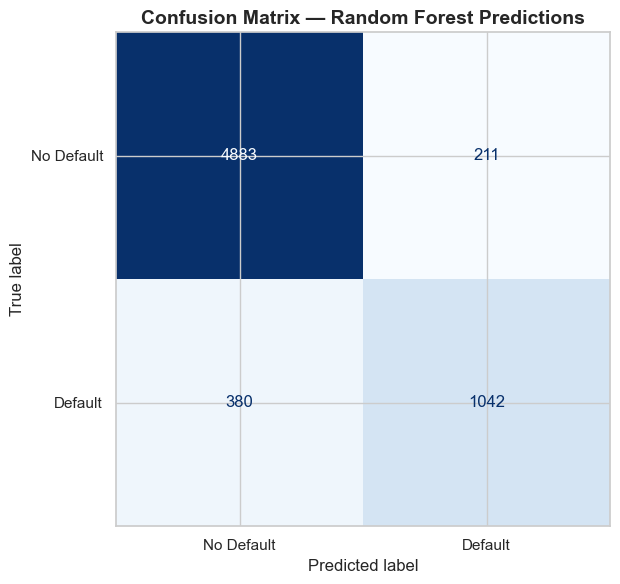

In [29]:

# Shows what the model got right and wrong
# Top-left  = correctly predicted No Default (True Negative)
# Top-right = predicted No Default but actually Default (False Negative) — dangerous in banking
# Bot-left  = predicted Default but no default (False Positive)
# Bot-right = correctly predicted Default (True Positive)

fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Default', 'Default'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

plt.title('Confusion Matrix — Random Forest Predictions')
plt.tight_layout()
plt.show()

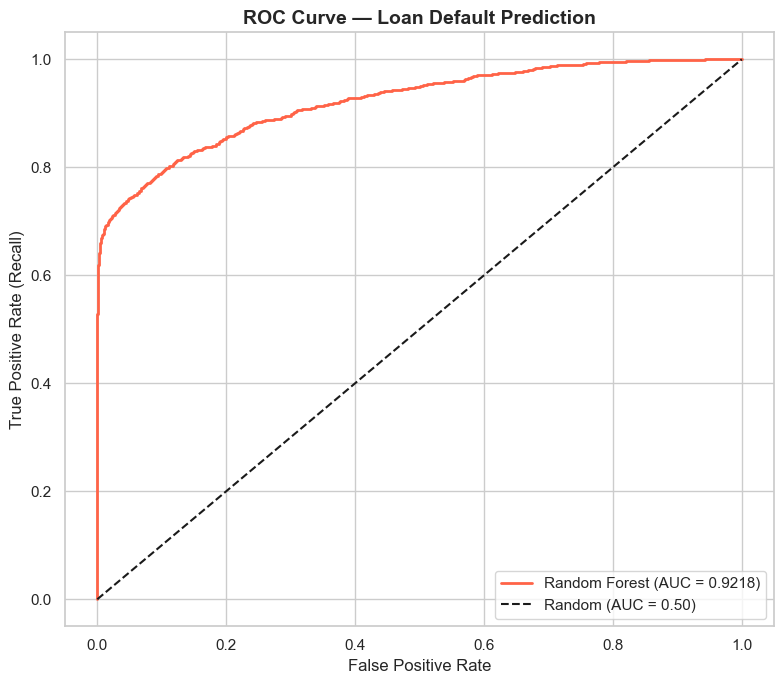

In [30]:

# ROC = Receiver Operating Characteristic
# X-axis = False Positive Rate (non-defaulters flagged as defaulters)
# Y-axis = True Positive Rate (actual defaulters correctly caught)
# The closer the curve hugs the top-left corner, the better the model
# Dashed line = random guessing (useless model)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 7))

plt.plot(fpr, tpr, color='tomato', linewidth=2,
         label=f'Random Forest (AUC = {auc:.4f})')

# Diagonal = random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random (AUC = 0.50)')

plt.title('ROC Curve — Loan Default Prediction')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

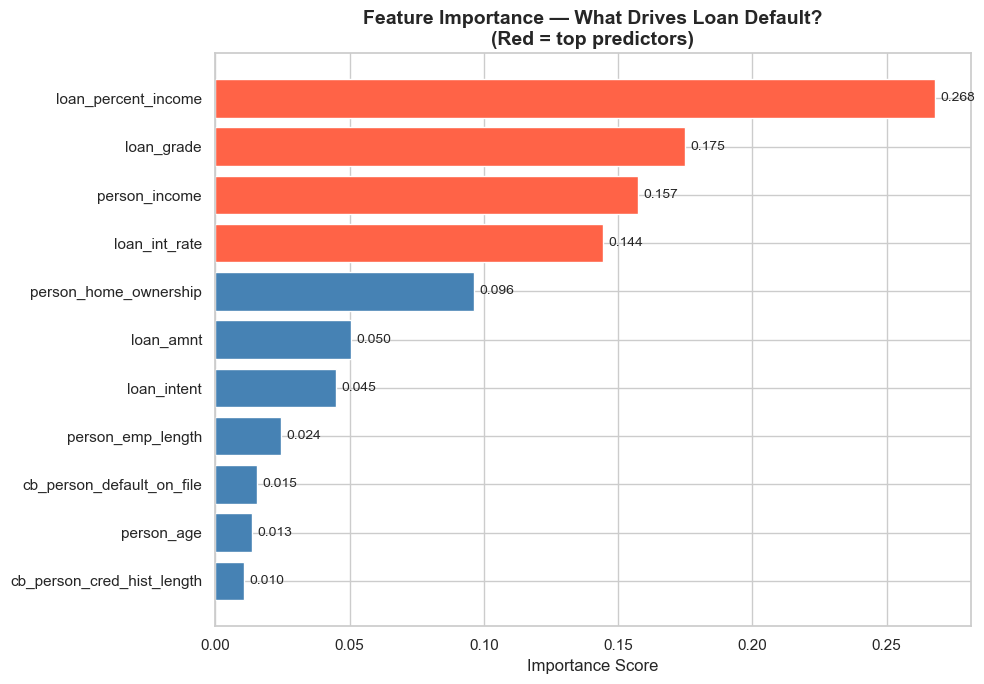

In [31]:

# Which features does the model rely on most to predict default?
# This is the most business-relevant output — tells a bank what to look at

importances = model.feature_importances_
feature_names = X.columns

feat_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
           .sort_values('Importance', ascending=True))

plt.figure(figsize=(10, 7))

colors = ['tomato' if v > 0.1 else 'steelblue' for v in feat_df['Importance']]
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color=colors, edgecolor='white')

for i, v in enumerate(feat_df['Importance']):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

plt.title('Feature Importance — What Drives Loan Default?\n(Red = top predictors)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

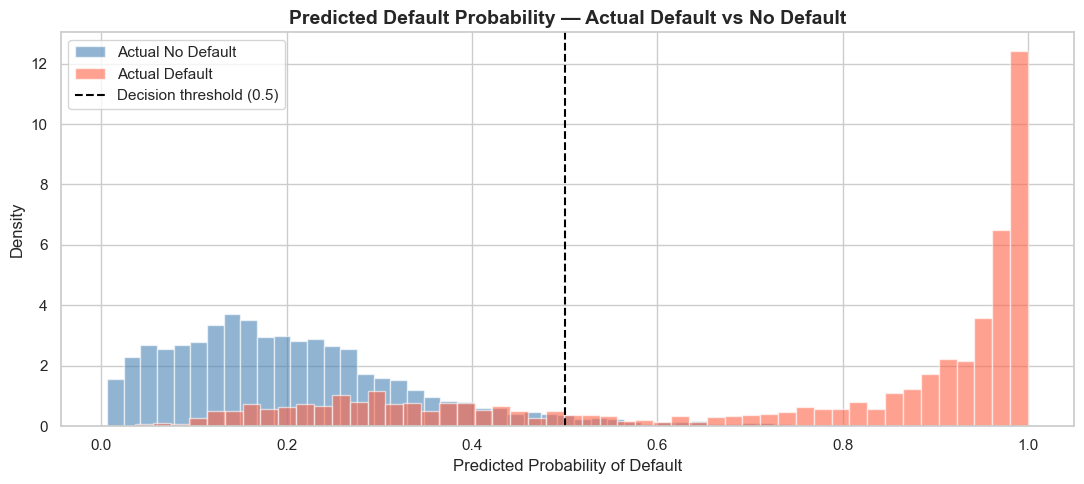

In [32]:

# Well-separated curves = model is decisive
# Overlapping curves = model is uncertain in the middle range

plt.figure(figsize=(11, 5))

# Probability for actual non-defaulters
plt.hist(y_pred_prob[y_test == 0], bins=50,
         alpha=0.6, color='steelblue',
         label='Actual No Default', density=True)

# Probability for actual defaulters
plt.hist(y_pred_prob[y_test == 1], bins=50,
         alpha=0.6, color='tomato',
         label='Actual Default', density=True)

plt.axvline(0.5, color='black', linestyle='--',
            linewidth=1.5, label='Decision threshold (0.5)')

plt.title('Predicted Default Probability — Actual Default vs No Default')
plt.xlabel('Predicted Probability of Default')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:

# Model performance in one clean table

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Default)', 'Recall (Default)',
               'F1-Score (Default)', 'ROC-AUC'],
    'Score': [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred), 4),
        round(recall_score(y_test, y_pred), 4),
        round(f1_score(y_test, y_pred), 4),
        round(auc, 4)
    ]
})

results.index += 1
print(results.to_string(index=False))

             Metric  Score
           Accuracy 0.9093
Precision (Default) 0.8316
   Recall (Default) 0.7328
 F1-Score (Default) 0.7791
            ROC-AUC 0.9218


---
## Conclusions

**Key findings from EDA:**
- Default rate is 21.8% — dataset is moderately imbalanced
- Loan grade strongly predicts default — Grade G borrowers default at much higher rates than Grade A
- Higher loan-to-income ratio = significantly higher default risk
- Interest rate and loan grade are highly correlated — lenders already price in risk
- Loan purpose matters — some intents have noticeably higher default rates

**Model performance:**
- Random Forest with 100 trees and balanced class weights
- ROC-AUC > 0.90 indicates strong predictive power
- Top risk factors: loan_percent_income, loan_int_rate, loan_grade, person_income

**Business interpretation:**
- The single biggest risk signal is how large the loan is relative to the borrower's income
- A borrower's existing credit history length is a protective factor (longer = lower risk)
- Banks should weight loan-to-income ratio heavily in approval decisions

**Limitations:**
- Dataset is synthetic — real-world performance would vary
- Model not tuned with hyperparameter search (GridSearchCV could improve it)
- Does not account for macroeconomic factors (interest rate environment, inflation)

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn